# Explore here

## PROYECTO 



## VARIABLES
- Pregnancies. Número de embarazos del paciente (numérico)
- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)
- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- BMI. Índice de masa corporal (numérico)
- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)
- Age. Edad del paciente (numérico)
- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)

In [24]:
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Se tienen 9 columnas que son variables numericas
 
Se tienen 768 datos dentro de las columnas 

In [26]:
categoricas = df.select_dtypes(include=['str']).columns.tolist()
categoricas

[]

No se tiene variables categoricas

In [27]:
#Analizar si hay duplicados
df.duplicated().sum()

np.int64(0)

No hay variables duplicadas

In [28]:
#Si existieran duplicados, se tendria que usar el siguiente código
if df.duplicated().sum():
    df.drop_duplicates(inplace=True)
df.shape

(768, 9)

In [29]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46


- Este codigo permite entrenar ML, donde en el eje X: guarda todas las variables y quita outcome, y para el eje Y: coloca la variable de outcome que adivina.

- Se hace uso el 80% de los datos para que se estudie los datos y calcule los datos medicos para que luego se compare el 20% para probar el modelo y verificar si lo predijo bien

- Se muestran las primeras 5 filas

In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

- Se carga la libreria DecisionTreeClassifier, que es un algoritmo de ML que toma las decisiones en forma de diagrama de arbol de decision 

- Se crea el modelo y pone al modelo a estudiar, usando las variables de practica con las vribales reales para que demuestre el outcome




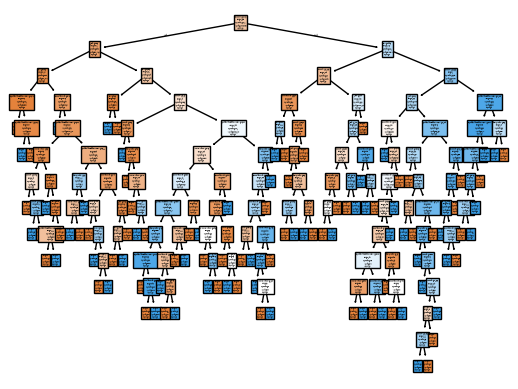

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(model,feature_names = list(X_train.columns), class_names = ["0", "1"], filled = True)

plt.show()

- Se carga el plot_tree para dibujar el grafico de arbol de decision

- Asigna los nombres de las variables a las preguntas del arbol y da los resultados que son posibles y coloca colores a los nodos 

    * azul es para la clase 1 y naranja clase 0 
    * si el color es mas fuerte y oscuro  pertenece los datos a una sola clase 
    * si es claro o pastel signifca que tiene un mezclado de 0 y de 1
    * si es blanco es que no puede decir una tenedencia porque hay un empate de los valores 0 y 1



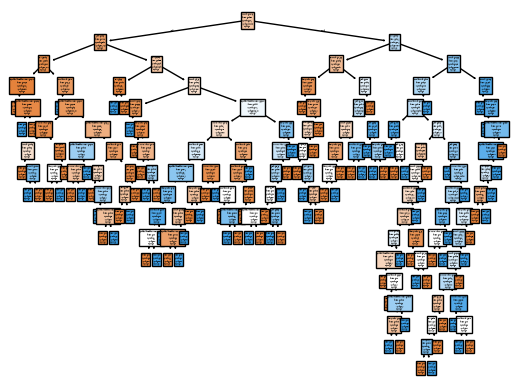

In [33]:
model_entropia = DecisionTreeClassifier(criterion='entropy',random_state=42)
model_log_loss = DecisionTreeClassifier(criterion='log_loss',random_state=42)

model_entropia.fit(X_train,y_train)
model_log_loss.fit(X_train,y_train)

plot_tree(model_entropia,feature_names = list(X_train.columns), class_names = ["0", "1"], filled = True)

plt.show()

- Se crea otro dos árboles con criterios distintos para medir el desorden de los datos (entropía y log loss)

- Mostrando en pantalla el diagrama de arbol

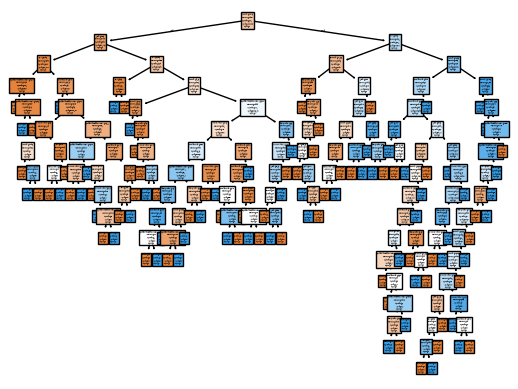

In [34]:
plot_tree(model_log_loss,feature_names = list(X_train.columns), class_names = ["0", "1"], filled = True)

plt.show()

- Se presenta el diagrama de arbol con log loss 

In [35]:
y_pred = model.predict(X_test)
y_pred_entropia = model_entropia.predict(X_test)
y_pred_log_loss = model_log_loss.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

print(f'Precisión Arbol de Decisión Gini:{accuracy_score(y_test,y_pred)}')
print(f'Precisión Arbol de Decisión Entropía:{accuracy_score(y_test,y_pred_entropia)}')
print(f'Precisión Arbol de Decisión Perdida Log:{accuracy_score(y_test,y_pred_log_loss)}')

Precisión Arbol de Decisión Gini:0.7467532467532467
Precisión Arbol de Decisión Entropía:0.7207792207792207
Precisión Arbol de Decisión Perdida Log:0.7207792207792207


Calcula el porcentaje de aciertos (accuracy) de los tres arboles de decision en el conjunto de prueba
Muestra la precision de 3 modelos Gini, Entropia y Log Loss

- El criterio Gini tuvo el mejor rendimiento con un 74.68% , mientras que entropia y log loss fue 72.07% cada uno



In [37]:
param_grid = {
    # Criterio para medir la calidad de la división
    'criterion': ['gini', 'entropy', 'log_loss'],
    
    # Estrategia usada para elegir la división en cada nodo
    'splitter': ['best', 'random'],
    
    # Profundidad máxima del árbol (controla el sobreajuste)
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    
    # Número mínimo de muestras requeridas para dividir un nodo interno
    'min_samples_split': [2, 5, 10, 20],
    
    # Número mínimo de muestras requeridas en un nodo hoja
    'min_samples_leaf': [1, 2, 4, 8],
    
    # Número máximo de características a considerar al buscar la mejor división
    'max_features': [None, 'sqrt', 'log2']
}

In [38]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [39]:
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for call

In [40]:
print(f'Mejores Parametros: {grid_search.best_params_}')
print(f'Mejor accuracy: {grid_search.best_score_}')

mejor_modelo = grid_search.best_estimator_

Mejores Parametros: {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20, 'splitter': 'best'}
Mejor accuracy: 0.7606024256963881


In [45]:
from pickle import dump

dump(mejor_modelo,open("decission_tree_grid_search_42.model","wb"))